# Atributos estruturais de gênero

In [ ]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import torch

ROOT = Path.cwd()
while not (ROOT / "data" / "genre_network").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

REGIMES = {
    "current":      [2017, 2018, 2019],  # split usado desde a qualificação; treino vai até jun/2020,
                                          # mas o arquivo de 2020 é anual e mistura com teste/validação
    "pre_pandemia":   [2017, 2018],      # split novo (ainda não rodado); treino vai até dez/2018
}

## Antes — tabela aprendida, 530×32

In [2]:
torch.manual_seed(0)
x_genre_antigo = torch.empty(530, 32).normal_(0, 0.1)

print(x_genre_antigo.shape)
print(x_genre_antigo[0, :6])

torch.Size([530, 32])
tensor([-0.1126, -0.1152, -0.0251, -0.0434,  0.0849,  0.0692])


## Depois — atributos derivados da rede gênero↔gênero, por regime de split

`data/genre_network/br-genre_network-{ano}.csv` traz um par (Source, Target, Weight) por
linha: dois gêneros que coocorreram (uma música/artista com os dois) e quantas vezes.
Duas correções em relação à primeira versão: **linhas onde Source == Target** (um gênero
"coocorrendo com ele mesmo") não descrevem relação com outro gênero e são descartadas; e o
mesmo par pode aparecer em mais de um arquivo de ano, então os anos são agregados (soma dos
pesos) **antes** de contar grau, não depois — senão o mesmo vizinho é contado uma vez por ano
em que a relação aparece.

In [3]:
def rede_genero(train_years):
    net = pd.concat([
        pd.read_csv(ROOT / "data" / "genre_network" / f"br-genre_network-{y}.csv",
                    usecols=["Source", "Target", "Weight"])  # Avg_Popularity/Avg_Streams nunca lidas
        for y in train_years
    ], ignore_index=True)
    net = net[net["Source"] != net["Target"]]                       # sem self-loop
    return net.groupby(["Source", "Target"], as_index=False)["Weight"].sum()  # 1 aresta por par, soma entre anos


def atributos_genero(train_years):
    net = rede_genero(train_years)

    degree = pd.concat([net["Source"], net["Target"]]).value_counts().rename("degree")
    weighted_degree = (
        pd.concat([net.groupby("Source")["Weight"].sum(), net.groupby("Target")["Weight"].sum()])
        .groupby(level=0).sum()
        .rename("weighted_degree")
    )

    artists = pd.concat([
        pd.read_csv(ROOT / "data" / "artists" / f"br-artists-{y}.csv",
                    sep="\t", usecols=["artist_id", "genres"])
        for y in train_years
    ], ignore_index=True).drop_duplicates("artist_id")
    artists["genres_list"] = artists["genres"].apply(lambda v: ast.literal_eval(v) if isinstance(v, str) else [])
    n_artists = (
        artists.explode("genres_list").dropna(subset=["genres_list"])
        .groupby("genres_list")["artist_id"].nunique()
        .rename("n_artists")
    )

    return pd.concat([degree, weighted_degree, n_artists], axis=1).fillna(0).sort_values("weighted_degree", ascending=False)


resultados = {nome: atributos_genero(anos) for nome, anos in REGIMES.items()}

### `current` (2017–2019)

In [4]:
resultados["current"].head(10)

,degree,weighted_degree,n_artists
pop,234.0,2862.0,121.0
funk carioca,120.0,1722.0,119.0
sertanejo universitario,111.0,1715.0,88.0
rap,148.0,1424.0,60.0
pop nacional,141.0,1378.0,35.0
arrocha,59.0,1043.0,36.0
sertanejo,42.0,1007.0,62.0
dance pop,139.0,987.0,36.0
hip hop,139.0,925.0,34.0
brazilian hip hop,69.0,853.0,52.0


### `pre_pandemia` (2017–2018)

In [5]:
resultados["pre_pandemia"].head(10)

,degree,weighted_degree,n_artists
pop,192.0,2175.0,110.0
sertanejo universitario,93.0,1145.0,77.0
rap,135.0,1100.0,50.0
funk carioca,87.0,1020.0,91.0
dance pop,129.0,840.0,33.0
pop nacional,103.0,800.0,30.0
hip hop,120.0,752.0,30.0
sertanejo,35.0,673.0,57.0
trap,103.0,667.0,31.0
edm,124.0,647.0,33.0


### Os dois lado a lado, mesmo gênero

In [6]:
comparacao = pd.concat(
    {nome: df["weighted_degree"] for nome, df in resultados.items()}, axis=1
).fillna(0)
comparacao.loc[comparacao["current"].sort_values(ascending=False).head(10).index]

,current,pre_pandemia
pop,2862.0,2175.0
funk carioca,1722.0,1020.0
sertanejo universitario,1715.0,1145.0
rap,1424.0,1100.0
pop nacional,1378.0,800.0
arrocha,1043.0,641.0
sertanejo,1007.0,673.0
dance pop,987.0,840.0
hip hop,925.0,752.0
brazilian hip hop,853.0,402.0


## De onde vem `n_artists`

`data/artists/br-artists-{ano}.csv` tem uma linha por artista com hit naquele ano, e uma
coluna `genres` (lista de tags, ex. `['forro', 'sertanejo', 'sertanejo universitario']`).
As tags de um artista não mudam entre os arquivos de ano (checado abaixo), então concatenar
os anos e tirar duplicata de `artist_id` só evita contar o mesmo artista mais de uma vez, sem
perder informação. Depois é só "explodir" a lista (uma linha por par artista-gênero) e contar
`artist_id` únicos por gênero.

In [7]:
a17 = pd.read_csv(ROOT / "data" / "artists" / "br-artists-2017.csv", sep="\t", usecols=["artist_id", "name", "genres"])
a18 = pd.read_csv(ROOT / "data" / "artists" / "br-artists-2018.csv", sep="\t", usecols=["artist_id", "name", "genres"])
comuns = set(a17["artist_id"]) & set(a18["artist_id"])
checagem = a17.set_index("artist_id").loc[list(comuns)[:5], ["name", "genres"]].join(
    a18.set_index("artist_id")["genres"], lsuffix="_2017", rsuffix="_2018"
)
checagem["genres_2017"] == checagem["genres_2018"]

artist_id
6tRBlIPvgIrWAJc93ppbag    True
7n2wHs1TKAczGzO7Dd2rGr    True
4tZwfgrHOc3mvqYlEYSvVi    True
5WUlDfRSoLAfcVSX1WnrxN    True
5yG7ZAZafVaAlMTeBybKAL    True
dtype: bool

## O grafo gênero↔gênero (`current`, top 40 por grau ponderado)

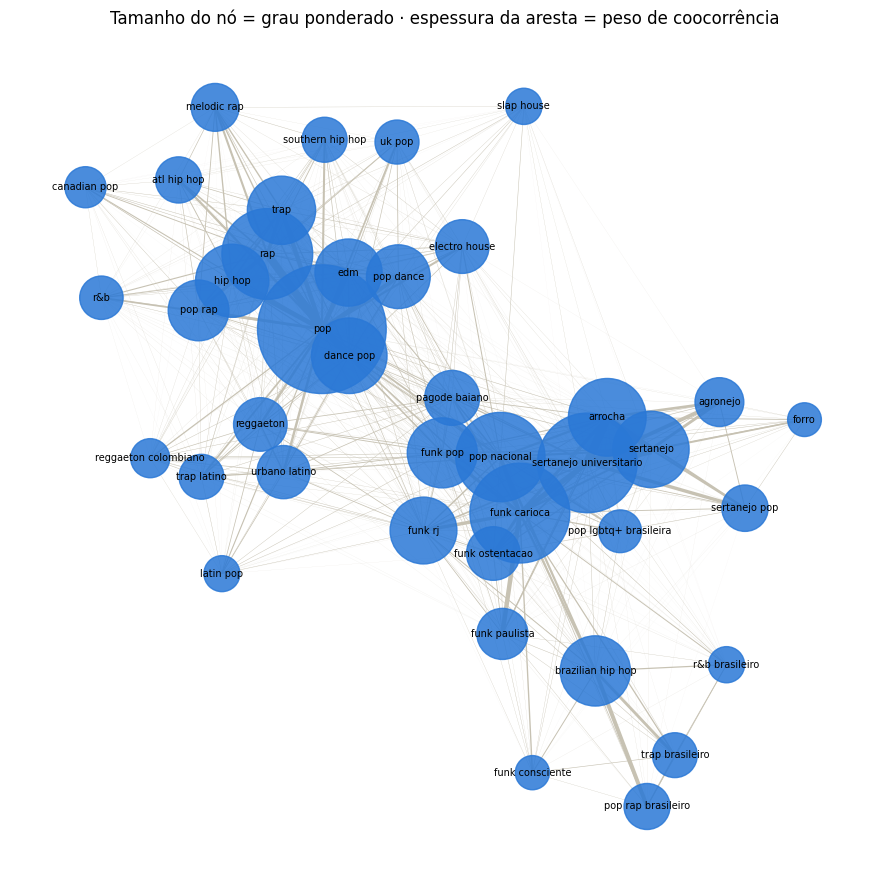

In [8]:
net = rede_genero(REGIMES["current"])
G = nx.from_pandas_edgelist(net, "Source", "Target", edge_attr="Weight")

wdeg = dict(G.degree(weight="Weight"))
top_nodes = sorted(wdeg, key=wdeg.get, reverse=True)[:40]
H = G.subgraph(top_nodes)

pos = nx.spring_layout(H, weight="Weight", seed=7, k=0.6)
fig, ax = plt.subplots(figsize=(9, 9))
nx.draw_networkx_edges(H, pos, width=[H[u][v]["Weight"] / 40 for u, v in H.edges()], edge_color="#c7c2b3", ax=ax)
nx.draw_networkx_nodes(H, pos, node_size=[wdeg[n] * 3 for n in H.nodes()], node_color="#2a78d6", alpha=0.85, ax=ax)
nx.draw_networkx_labels(H, pos, font_size=7, ax=ax)
ax.axis("off")
ax.set_title("Tamanho do nó = grau ponderado · espessura da aresta = peso de coocorrência")
fig.tight_layout()
plt.show()

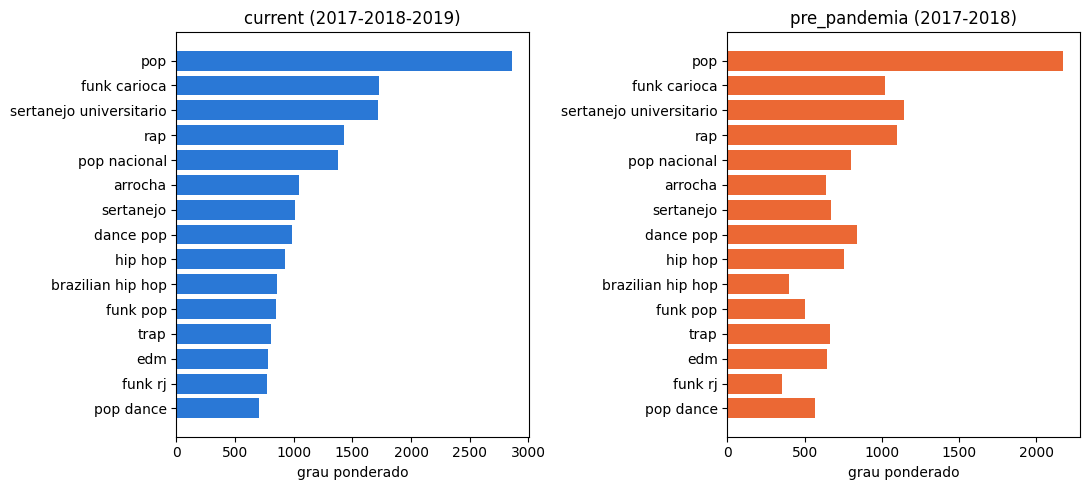

In [9]:
top = resultados["current"].head(15).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=False)
for ax, (nome, cor) in zip(axes, [("current", "#2a78d6"), ("pre_pandemia", "#eb6834")]):
    d = resultados[nome].reindex(top.index).fillna(0)
    ax.barh(d.index, d["weighted_degree"], color=cor)
    ax.set_xlabel("grau ponderado")
    ax.set_title(f"{nome} ({'-'.join(map(str, REGIMES[nome]))})")
fig.tight_layout()
plt.show()